#### Based upon: [Real VS Fake face CNN model](https://www.kaggle.com/code/abdalrhmanmorsi/real-vs-fake-face-cnn-model)

In [18]:
import os
import glob
import numpy as np
import cv2
from PIL import Image
import pandas as pd
from collections import Counter

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from torchvision import datasets, transforms, models

In [19]:
DATA_DIR = 'data'
NORMALIZED_DATA = './normalizedData/'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_DIR_NAMES = ['wiki_augmented', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki_augmented'
DATASET_SIZE = 18000

# ! Bath should change considering the memory of the GPU
BATCH_SIZE = 64

In [20]:
# Check if CUDA is available with PyTorch
print("Checking for available hardware...")
print('Using DEVICE:', DEVICE)
if DEVICE.type == 'cuda':
    torch.cuda.memory_summary(device=None, abbreviated=False)
    torch.cuda.empty_cache()  # Clear CUDA cache
    
    # Enable CUDA benchmarking for optimal performance
    torch.backends.cudnn.benchmark = True

    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU found, using CPU instead")

Checking for available hardware...
Using DEVICE: cuda
CUDA Device: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Memory: 17.17 GB


In [21]:
# Loading of the images
def load__images(data_dir):
    dataset = {"origin_dir": [],"image_path":[], "img_status":[]}

    print(f"Loading and preprocessing images from {data_dir}...")
    for main_folder in IMG_DIR_NAMES:
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            dataset["origin_dir"].append(main_folder)
                            dataset["image_path"].append(img_path)
                            dataset["img_status"].append("real" if main_folder == REAL_IMG_DIR else "fake")
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")

    dataset = pd.DataFrame(dataset)
    return dataset

In [22]:
dataset = load__images(DATA_DIR)
dataset

Loading and preprocessing images from data...
Processing directory wiki_augmented...
Processing directory inpainting...
Processing directory insight...
Processing directory text2img...


,origin_dir,image_path,img_status
0,wiki_augmented,data\wiki_augmented\00\10049200_1891-09-16_195...,real
1,wiki_augmented,data\wiki_augmented\00\10049200_1891-09-16_195...,real
2,wiki_augmented,data\wiki_augmented\00\10049200_1891-09-16_195...,real
3,wiki_augmented,data\wiki_augmented\00\10110600_1985-09-17_201...,real
4,wiki_augmented,data\wiki_augmented\00\10110600_1985-09-17_201...,real
...,...,...,...
179995,text2img,data\text2img\99\9611799_1955-03-22_2012.jpg,fake
179996,text2img,data\text2img\99\9799_1960-06-22_2012.jpg,fake
179997,text2img,data\text2img\99\9811999_1953-06-14_2004.jpg,fake
179998,text2img,data\text2img\99\9863599_1948-08-13_1963.jpg,fake


In [23]:
dataset.value_counts("img_status")

img_status
fake    90000
real    90000
Name: count, dtype: int64

Real: 90000,
Fake: 90000



C:\Users\Cristiano\AppData\Local\Temp\ipykernel_20984\3809996067.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real = dataset.value_counts("img_status")[1]
C:\Users\Cristiano\AppData\Local\Temp\ipykernel_20984\3809996067.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fake = dataset.value_counts("img_status")[0]


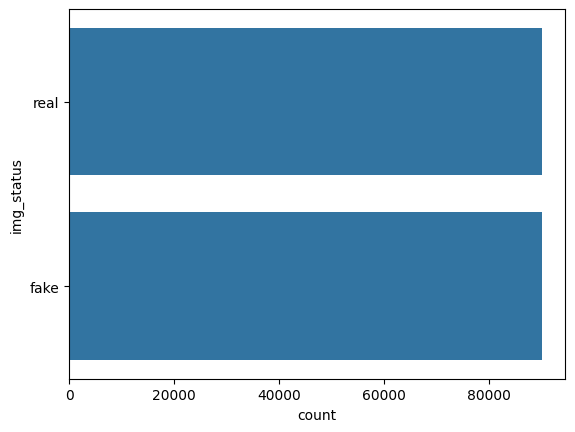

In [24]:
real = dataset.value_counts("img_status")[1]
fake = dataset.value_counts("img_status")[0]

print(f"Real: {real},\nFake: {fake}\n")
sns.countplot(dataset["img_status"])
plt.show()

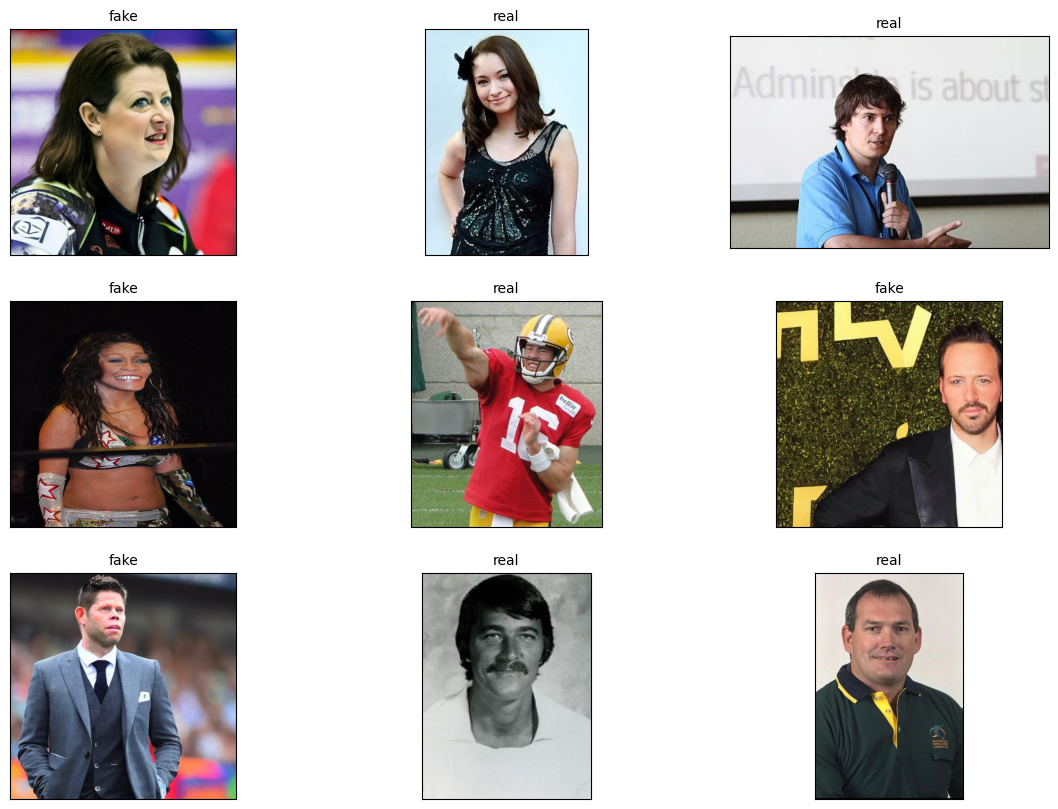

In [25]:
plt.figure(figsize = (14,10))
for i in range(9):
    random = np.random.randint(1,len(dataset))
    plt.subplot(3,3,i+1)
    plt.imshow(plt.imread(dataset.loc[random,"image_path"]))
    plt.title(dataset.loc[random, "img_status"], size = 10) 
    plt.xticks([])
    plt.yticks([])
    
plt.show()

In [26]:
# import os
# from PIL import Image
# import shutil  # For copying files

# # Create normalized data directory if it doesn't exist
# os.makedirs(NORMALIZED_DATA, exist_ok=True)

# def organize_images():
#     total_images = len(dataset)
#     processed = 0
    
#     # Create subdirectories for real and fake images
#     real_dir = os.path.join(NORMALIZED_DATA, 'real')
#     fake_dir = os.path.join(NORMALIZED_DATA, 'fake')
#     os.makedirs(real_dir, exist_ok=True)
#     os.makedirs(fake_dir, exist_ok=True)
    
#     for idx, row in dataset.iterrows():
#         if idx % 1000 == 0:
#             print(f"Processing image {idx}/{total_images}")
        
#         try:
#             # Load image path
#             img_path = row['image_path']
            
#             # Determine the target directory based on the label
#             save_dir = real_dir if row['img_status'] == 'real' else fake_dir
            
#             # Create the new filename
#             filename = os.path.basename(img_path)
#             save_path = os.path.join(save_dir, (row["origin_dir"] + "_" + filename))
            
#             # Copy the image to the target directory
#             shutil.copy(img_path, save_path)
            
#             processed += 1
            
#         except Exception as e:
#             print(f"Error processing {img_path}: {e}")
    
#     print(f"Organizing complete. {processed}/{total_images} images processed successfully.")

# # Run the organizing function
# organize_images()

In [27]:
class DenseNetBinaryClassifier(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.5):
        super(DenseNetBinaryClassifier, self).__init__()
        
        # 1. Base DenseNet121 model without classifier
        weights = 'IMAGENET1K_V1' if pretrained else None
        self.densenet = models.densenet121(weights=weights)
        
        # 2. Modify first conv layer for grayscale input (1 channel)
        original_conv = self.densenet.features.conv0
        original_weights = original_conv.weight.clone() if pretrained else None
        
        self.densenet.features.conv0 = nn.Conv2d(
            in_channels=1,  # grayscale
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=(original_conv.bias is not None)
        )
        
        # Initialize the new conv layer with average of pre-trained weights
        if pretrained:
            self.densenet.features.conv0.weight.data = torch.mean(
                original_weights, dim=1, keepdim=True
            )
        
        
        # 3. Remove the original classifier
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()
        
        # 4. Add global average pooling (already part of DenseNet but we make it explicit)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 5. Add our custom classifier with sigmoid (equivalent to Dense(1, activation='sigmoid')) with dropout to prevent overfitting
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
    def freeze_early_layers(self, num_blocks=3):
        """
        Freeze early layers of DenseNet
        DenseNet has 4 dense blocks - each with multiple layers
        num_blocks controls how many dense blocks to freeze
        """
        # Find and freeze transition layers and first N dense blocks
        ct = 0
        for name, child in self.densenet.features.named_children():
            # Freeze initial layers and first N dense blocks
            if 'denseblock' in name:
                ct += 1
                if ct <= num_blocks:  # Freeze first N dense blocks
                    for param in child.parameters():
                        param.requires_grad = False
                    print(f"Froze {name}")
            elif ct < num_blocks or 'norm0' in name or 'conv0' in name or 'pool0' in name:
                # Freeze initial conv, norm, pool and transition layers before block N
                for param in child.parameters():
                    param.requires_grad = False
                print(f"Froze {name}")
                
        print(f"Froze the first {num_blocks} dense blocks and related layers")
    
    def forward(self, x):
        # Get features from DenseNet
        x = self.densenet.features(x)
        
        # Apply global pooling
        x = self.global_pool(x)
        
        # Apply classifier
        x = self.classifier(x)
        
        return x


In [29]:
# Create the model
model = DenseNetBinaryClassifier()
model.freeze_early_layers()

# Define loss function (binary_crossentropy equivalent)
criterion = nn.BCELoss()

# Define optimizer (Adam equivalent)
optimizer = torch.optim.Adam(model.parameters())

model = model.to(DEVICE)

# Print model summary
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Froze conv0
Froze norm0
Froze relu0
Froze pool0
Froze denseblock1
Froze transition1
Froze denseblock2
Froze transition2
Froze denseblock3
Froze the first 3 dense blocks and related layers
DenseNetBinaryClassifier(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=Tr

In [30]:
fake_dir = os.path.join(NORMALIZED_DATA, 'fake')
fake_files = glob.glob(os.path.join(fake_dir, '*.pt'))
len(fake_files)

0

In [32]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define paths
real_dir = os.path.join(NORMALIZED_DATA, 'real')
fake_dir = os.path.join(NORMALIZED_DATA, 'fake')

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale if needed
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1]
])

# Create dataset using ImageFolder
dataset = datasets.ImageFolder(
    root=NORMALIZED_DATA,  # Root directory containing 'real' and 'fake' folders
    transform=transform
)

# Split dataset into train and test
train_size = int(0.8 * len(dataset))  # 80% for training
test_size = len(dataset) - train_size  # 20% for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=10,  # Use multiple workers for faster loading
    pin_memory=True,  # Speeds up data transfer to GPU
    persistent_workers=True,   # Keep workers alive between epochs
    prefetch_factor=2          # Pre-fetch batches
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=10,
    pin_memory=True,
    persistent_workers=True,   # Keep workers alive between epochs
    prefetch_factor=2          # Pre-fetch batches
)

# Print dataset sizes
print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 144000
Testing dataset size: 36000


In [33]:
# Function to train the model
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, patience=30, resume_from=None, save_dir="checkpoints"):    
    os.makedirs(save_dir, exist_ok=True)

    # Initialize variables
    best_accuracy = 0.0
    start_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    early_stopping_counter = 0
    best_val_loss = float('inf')
    
    print("Starting training...")
    
    # Setup scheduler
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=patience//2, verbose=True)
    
    # Resume from checkpoint if specified
    if resume_from and os.path.exists(resume_from):
        checkpoint = torch.load(resume_from)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        if 'best_accuracy' in checkpoint:
            best_accuracy = checkpoint['best_accuracy']
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"Resuming from epoch {start_epoch}, best accuracy: {best_accuracy:.4f}")
    
    for epoch in range(start_epoch, start_epoch + num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        val_loss, val_acc, all_preds, all_labels = validate_epoch(model, test_loader, criterion)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{start_epoch + num_epochs}")
        print(f"Training Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
        print(f"Validation Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early stopping check
        early_stopping_counter = check_early_stopping(val_loss, best_val_loss, early_stopping_counter)
        if early_stopping_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        # Update best validation loss
        best_val_loss = min(val_loss, best_val_loss)
        
        # Update scheduler
        scheduler.step(val_loss)

        # Save best model
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, 'best_model.pth'))
            print(f"Model saved with accuracy: {best_accuracy:.4f}")
        
        # Save checkpoint every 5 epochs
        if epoch % 5 == 0 or epoch == start_epoch + num_epochs - 1:
            save_checkpoint(model, optimizer, epoch, best_accuracy, history, save_dir)
        
    return model, history

def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs.squeeze() > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if i % 100 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")
        else:
            print(f"Batch {i}/{len(train_loader)}", end='\r')

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, test_loader, criterion):
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)

            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs.squeeze() > 0.5).float()
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_val_acc = val_correct / val_total
    return epoch_val_loss, epoch_val_acc, all_preds, all_labels

def check_early_stopping(current_loss, best_loss, counter):
    if current_loss < best_loss:
        return 0
    else:
        return counter + 1

def save_checkpoint(model, optimizer, epoch, best_accuracy, history, save_dir):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_accuracy': best_accuracy,
        'history': history
    }
    torch.save(checkpoint, f'{save_dir}/checkpoint_epoch_{epoch}.pth')

Starting training...


C:\Users\Cristiano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Batch 0/2250 - Loss: 0.7047
Batch 100/2250 - Loss: 0.4386
Batch 200/2250 - Loss: 0.6523
Batch 300/2250 - Loss: 0.5280
Batch 400/2250 - Loss: 0.4382
Batch 500/2250 - Loss: 0.4705
Batch 600/2250 - Loss: 0.3775
Batch 700/2250 - Loss: 0.4093
Batch 800/2250 - Loss: 0.3460
Batch 900/2250 - Loss: 0.3751
Batch 1000/2250 - Loss: 0.3557
Batch 1100/2250 - Loss: 0.3775
Batch 1200/2250 - Loss: 0.3845
Batch 1300/2250 - Loss: 0.2988
Batch 1400/2250 - Loss: 0.4192
Batch 1500/2250 - Loss: 0.4277
Batch 1600/2250 - Loss: 0.3558
Batch 1700/2250 - Loss: 0.5222
Batch 1800/2250 - Loss: 0.2503
Batch 1900/2250 - Loss: 0.2745
Batch 2000/2250 - Loss: 0.3715
Batch 2100/2250 - Loss: 0.2262
Batch 2200/2250 - Loss: 0.2482
Epoch 1/5002250
Training Loss: 0.3868 Acc: 0.8175
Validation Loss: 0.3231 Acc: 0.8534
Model saved with accuracy: 0.8534
Batch 0/2250 - Loss: 0.3126
Batch 100/2250 - Loss: 0.3028
Batch 200/2250 - Loss: 0.2348
Batch 300/2250 - Loss: 0.2752
Batch 400/2250 - Loss: 0.3159
Batch 500/2250 - Loss: 0.2345
B

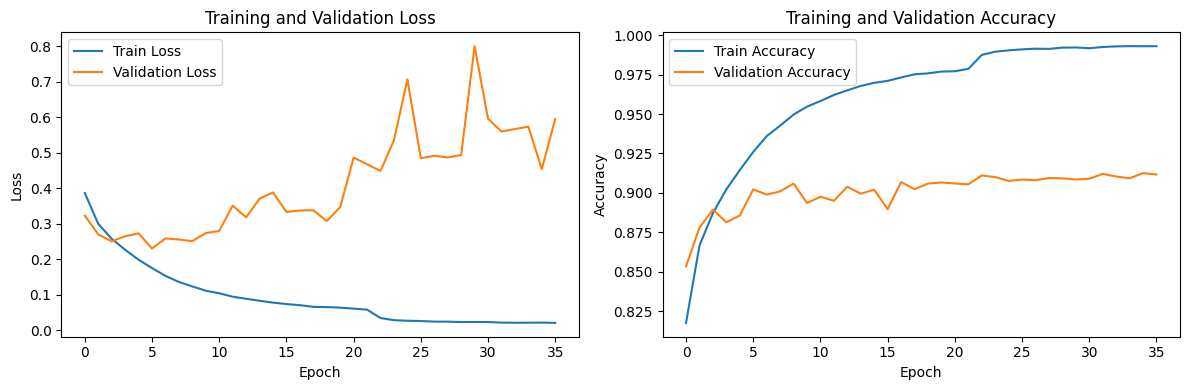

In [34]:
# Train the model
num_epochs = 500  # Adjust as needed
model, history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

        Fake       0.94      0.88      0.91     17825
        Real       0.89      0.94      0.92     18175

    accuracy                           0.91     36000
   macro avg       0.91      0.91      0.91     36000
weighted avg       0.91      0.91      0.91     36000



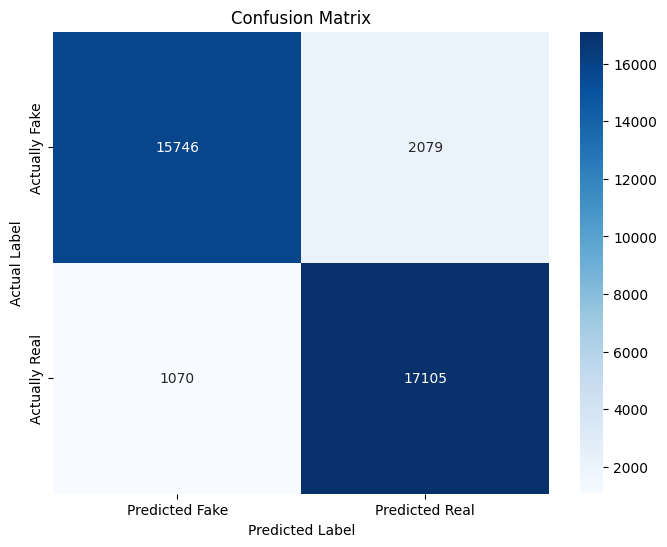

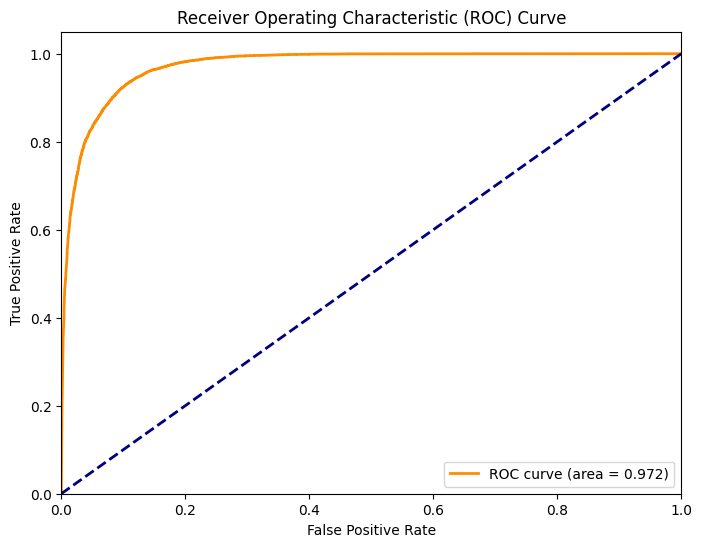

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load the best saved model
model.load_state_dict(torch.load('checkpoints/best_model.pth'))
model.eval()

# Lists to store predictions and ground truth
y_true = []
y_pred = []
y_scores = []

# Get predictions on test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        predicted = (outputs.squeeze() > 0.5).float()
        
        # Store results
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_scores.extend(outputs.squeeze().cpu().numpy())

# Calculate metrics

# Convert to binary labels (0 or 1)
y_true_binary = [int(i) for i in y_true]
y_pred_binary = [int(i) for i in y_pred]

# Print classification report
print("Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Fake', 'Real']))

# Create and plot confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actually Fake', 'Actually Real'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate and plot ROC curve
fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()